In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("/content/my data.xlsx")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1021 non-null   object
 1   race/ethnicity               1021 non-null   object
 2   parental level of education  1021 non-null   object
 3   lunch                        1021 non-null   object
 4   test preparation course      1021 non-null   object
 5   math score                   1021 non-null   int64 
 6   reading score                1021 non-null   int64 
 7   writing score                1021 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 63.9+ KB


,math score,reading score,writing score
count,1021.000000,1021.000000,1021.000000
mean,66.133203,69.447600,68.181195
std,15.053300,14.584388,15.092118
min,0.000000,17.000000,10.000000
25%,57.000000,60.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,80.000000,79.000000
max,100.000000,100.000000,100.000000


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#2. Data Prepocessing

**Cek Outlier**

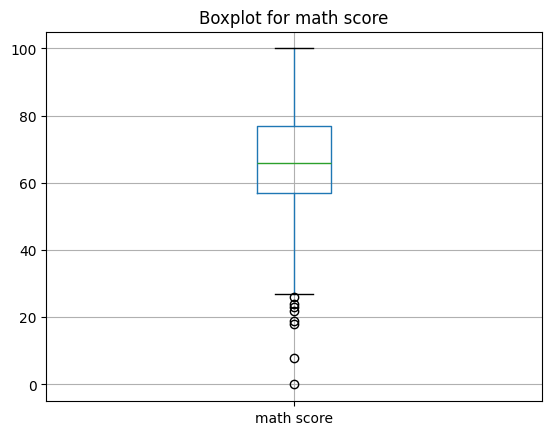

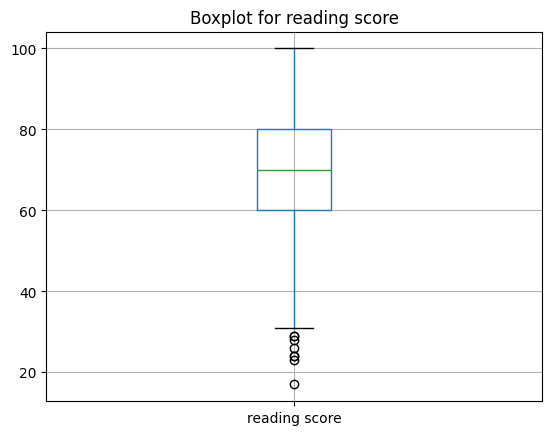

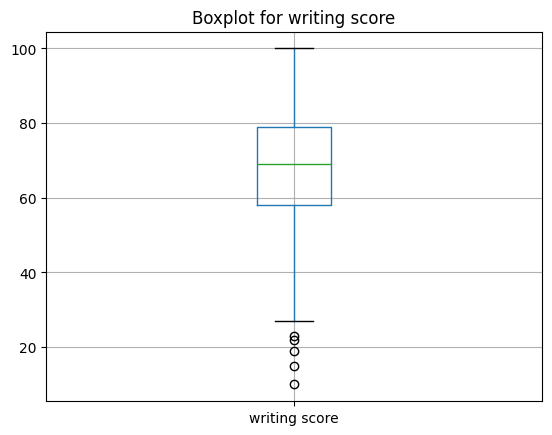

In [ ]:
numerical_col = df.select_dtypes(include=np.number).columns

for col in numerical_col:
    plt.figure()
    df.boxplot(column=col)
    plt.title(f"Boxplot for {col}")
    plt.show()


Dari hasil cek outlier data yang outlier adalah match score, reading score dan writing score

**handel Outlier**

In [ ]:
column = ['math score', 'reading score', 'writing score']

# Hitung batasan IQR
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)
IQR = Q3 - Q1


# Filter data (hapus outlier)
df_clean = df[~((df[column] < (Q1 - 1.5 * IQR)) |
                (df[column] > (Q3 + 1.5 * IQR))).any(axis=1)]

# Check how many rows were removed
print(f"Original rows: {df.shape[0]}")
print(f"Rows after outlier removal: {df_clean.shape[0]}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

# Update df
df = df_clean

Original rows: 1021
Rows after outlier removal: 1007
Rows removed: 14


**proses Encoding**

In [ ]:
df['gender'] = df['gender'].map({'female': 0, 'male': 1})

df['lunch'] = df['lunch'].map({'standard': 1, 'free/reduced': 0})

df['test preparation course'] = df['test preparation course'].map({
    'none': 0,
    'completed': 1
})

# One Hot Encoding (kategori banyak)
df = pd.get_dummies(df, columns=[
    'race/ethnicity',
    'parental level of education'
])

In [ ]:
df.head()

,gender,lunch,test preparation course,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,...,parental level of education_High school,parental level of education_Master's Degree,parental level of education_Some College,parental level of education_Some High School,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school
0,0,1,0,72,72,74,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
1,0,1,1,69,90,88,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,0,1,0,90,95,93,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,1,0,0,47,57,44,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,1,1,0,76,78,75,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False


#3 **Exploralation Data Analysisis (EDA)**

**Lihat Distribusi Data**

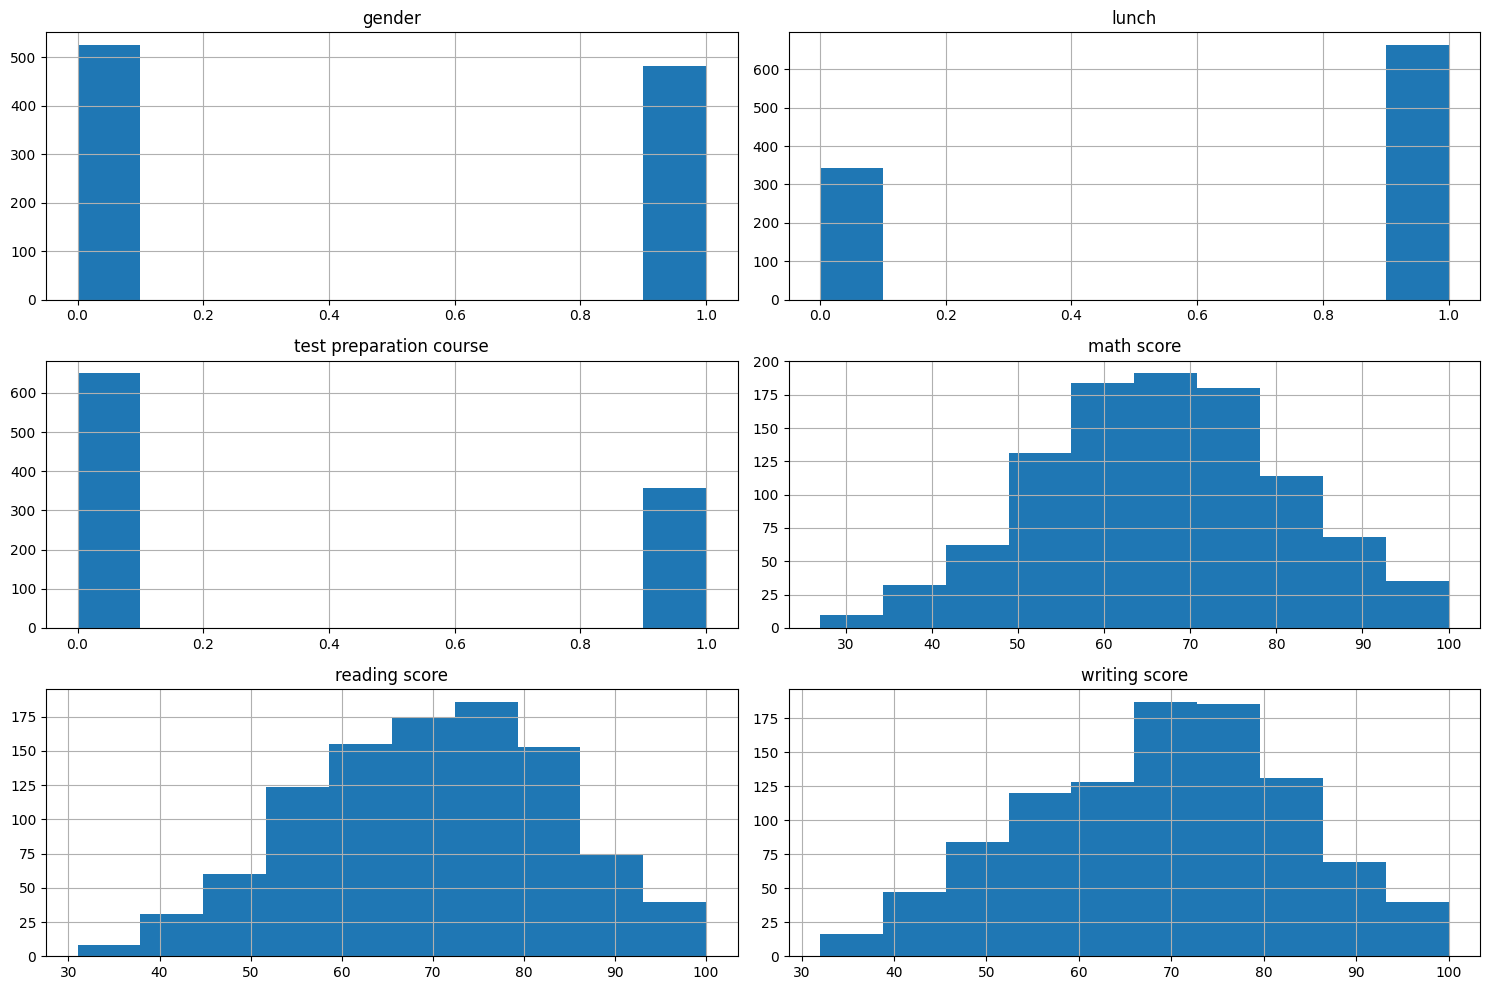

In [ ]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

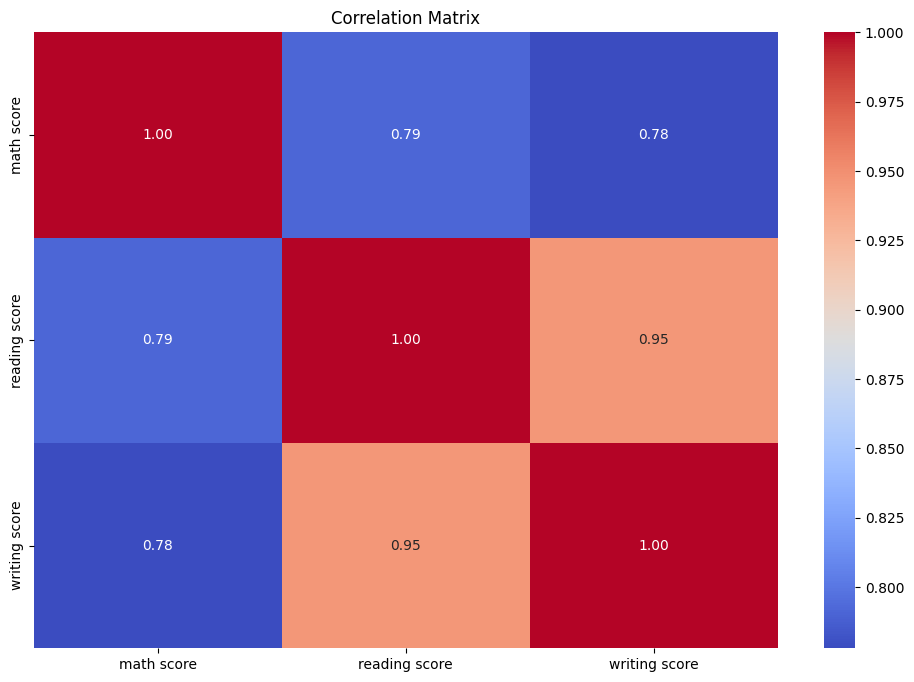

In [ ]:
corr = df[numerical_col].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

#split Data
X = df.drop(columns=['math score'])
y = df['math score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


#4 **Pemodelan**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

=== Linear Regression ===
MAE: 4.284480888882709
MSE: 30.353138058321512
R2 Score: 0.8602523853756328


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("\n=== Gradient Boosting ===")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("R2 Score:", r2_score(y_test, y_pred_gb))


=== Gradient Boosting ===
MAE: 4.607744775911589
MSE: 33.12981471979776
R2 Score: 0.8474684043823373


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n=== Random Forest ===")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))



=== Random Forest ===
MAE: 4.920209485420603
MSE: 37.671034197407415
R2 Score: 0.8265603655409405


#5 **Membuat Comprasion**

In [ ]:
# hitung semua metric
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# buat tabel
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [mae_lr, mae_rf, mae_gb],
    'MSE': [mse_lr, mse_rf, mse_gb],
    'R2 Score': [r2_lr, r2_rf, r2_gb]
})

print(comparison)

               Model       MAE        MSE  R2 Score
0  Linear Regression  4.284481  30.353138  0.860252
1      Random Forest  4.920209  37.671034  0.826560
2  Gradient Boosting  4.607745  33.129815  0.847468


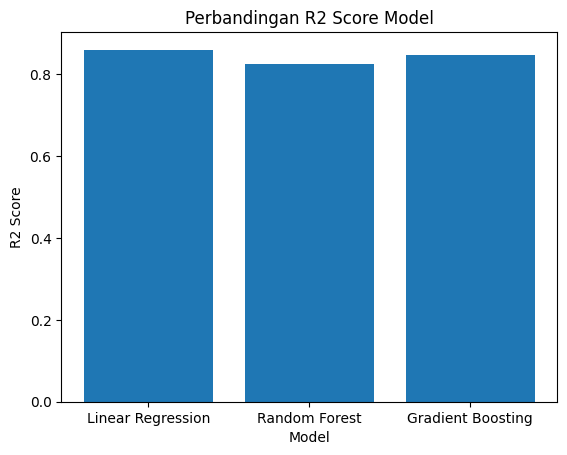

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison['Model'], comparison['R2 Score'])
plt.title('Perbandingan R2 Score Model')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.show()

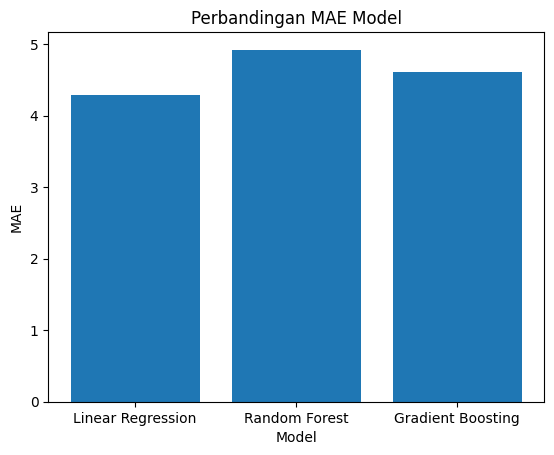

In [ ]:
plt.figure()
plt.bar(comparison['Model'], comparison['MAE'])
plt.title('Perbandingan MAE Model')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=500,      # tambah jumlah tree
    max_depth=15,          # kedalaman tree
    min_samples_split=2,   # minimal split
    min_samples_leaf=1,    # minimal leaf
    max_features='sqrt',   # jumlah fitur per split
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest Tuned ===")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

NameError: name 'X_train' is not defined